# 01. Thiết lập Dự án & Môi trường (Project Setup)
Cài đặt thư viện cốt lõi, thiết lập hạt giống tái lập thực nghiệm và cấu hình thiết bị tính toán.

In [12]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

try:
    from IPython.display import display
except ImportError:
    display = print

def bootstrap_project_dir() -> Path:
    search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for root in search_roots:
        candidates = [root, root / 'plan']
        for candidate in candidates:
            if (candidate / 'src').exists():
                if str(candidate) not in sys.path:
                    sys.path.append(str(candidate))
                from src.paths import find_project_dir
                return find_project_dir(candidate)
    raise FileNotFoundError('Không tìm thấy thư mục project plan chứa src/. Hãy chạy notebook từ repo hoặc thư mục plan.')


PROJECT_DIR = bootstrap_project_dir()

from src.data import (
    ProjectPaths,
    ensure_directories,
    create_metadata_splits,
    load_metadata,
    get_num_classes,
    build_data_loader,
)
from src.models import get_tiny_cnn
from src.train import train_model, evaluate_model
from src.utils import set_seed, get_device, get_pin_memory, get_num_workers, get_basic_transform
from src.visualization import set_publication_style, plot_confusion_heatmap

SEED = 42
set_seed(SEED)
set_publication_style()

DEVICE = get_device()
print(f"Thiết bị sử dụng: {DEVICE}")

PATHS = ProjectPaths(PROJECT_DIR)
BASE_DIR = PATHS.base_dir
METADATA_DIR = PATHS.metadata_dir
RESULTS_DIR = PATHS.results_dir('03_dataset_baseline_evaluation')
REPORTS_DIR = PATHS.reports_dir('03_dataset_baseline_evaluation')

ensure_directories(
    METADATA_DIR,
    RESULTS_DIR,
    REPORTS_DIR,
    RESULTS_DIR / 'saved_models',
    RESULTS_DIR / 'confusion_matrices',
)

USE_SUBSET = True
SUBSET_SIZE = 100
IMAGE_SIZE = 224
NUM_WORKERS = get_num_workers(DEVICE, notebook_safe=True)
PIN_MEMORY = get_pin_memory(DEVICE)



Thiết bị sử dụng: mps


# 02. Phân tách và Nạp Metadata (Metadata Split)
Chia tập dữ liệu Stratified Split 80/10/10 đồng bộ và lưu trữ để phục vụ so sánh chéo.

In [13]:
if not (METADATA_DIR / 'train.csv').exists():
    create_metadata_splits(BASE_DIR, METADATA_DIR, dataset_name='color', seed=SEED)
    print('Đã tạo xong các tệp phân tách metadata.')

train_df, val_df, test_df, class_map_df = load_metadata(METADATA_DIR)
NUM_CLASSES = get_num_classes(class_map_df=class_map_df)
class_names_list = class_map_df.sort_values('class_id')['class_name'].tolist()

if USE_SUBSET:
    train_df = train_df.groupby('class_id').head(SUBSET_SIZE).reset_index(drop=True)
    val_df = val_df.groupby('class_id').head(max(10, SUBSET_SIZE // 5)).reset_index(drop=True)
    test_df = test_df.groupby('class_id').head(max(10, SUBSET_SIZE // 5)).reset_index(drop=True)
    print(f"[Cơ chế chạy nhanh] Train={len(train_df)} | Val={len(val_df)} | Test={len(test_df)}")
else:
    print(f"[Dữ liệu đầy đủ] Train={len(train_df)} | Val={len(val_df)} | Test={len(test_df)}")

print(f'Số class: {NUM_CLASSES}')



[Cơ chế chạy nhanh] Train=3800 | Val=755 | Test=755
Số class: 38


# 03. Pipeline Nạp Dữ liệu PyTorch (Dataset Pipeline)
Định nghĩa PyTorch Dataset đơn giản và sạch sẽ, tự động giải quyết các tên file segmented khác biệt một cách trực quan.

In [14]:
transform_pipeline = get_basic_transform(IMAGE_SIZE)

print('Dataset pipeline dùng chung: src.data.PlantDataset thông qua build_data_loader().')
print(f'Transform chuẩn: Resize({IMAGE_SIZE}, {IMAGE_SIZE}) + ToTensor + ImageNet normalization.')



Dataset pipeline dùng chung: src.data.PlantDataset thông qua build_data_loader().
Transform chuẩn: Resize(224, 224) + ToTensor + ImageNet normalization.


# 04. Định nghĩa Mạng SimpleCNN tự thiết kế
Định nghĩa kiến trúc mạng SimpleCNN siêu nhẹ dùng Global Average Pooling tối giản.

In [15]:
print('SimpleCNN baseline được gọi bằng src.models.get_tiny_cnn().')



SimpleCNN baseline được gọi bằng src.models.get_tiny_cnn().


# 05. Ghi chú về phạm vi Phase 03

Phase 03 chỉ dùng **SimpleCNN/TinyCNN** để tạo baseline ban đầu cho các biến thể dữ liệu (`color`, `grayscale`, `segmented`).

MobileNetV2 và các mô hình pretrained hiện đại chỉ bắt đầu ở Phase 08 để tránh trộn baseline đơn giản với transfer learning.


In [16]:
print('Phase 03 chỉ chạy SimpleCNN/TinyCNN baseline, không dùng MobileNetV2.')


Phase 03 chỉ chạy SimpleCNN/TinyCNN baseline, không dùng MobileNetV2.


# 06. Quy trình Huấn luyện & Đánh giá (Train & Eval Pipeline)
Hàm huấn luyện và đánh giá mô hình tối giản, có Early Stopping và tính toán Macro F1.

In [ ]:
print('Train/evaluate pipeline dùng chung: src.train.train_model   và src.train.evaluate_model.')
print('Checkpoint tốt nhất được chọn theo Validation Macro F1 để nhất quán với các phase sau.')



Train/evaluate pipeline dùng chung: src.train.train_model và src.train.evaluate_model.
Checkpoint tốt nhất được chọn theo Validation Macro F1 để nhất quán với các phase sau.


# 07. Chạy 3 thực nghiệm baseline bằng SimpleCNN

Mỗi biến thể dữ liệu được đánh giá bằng cùng một mô hình SimpleCNN/TinyCNN để so sánh công bằng ảnh hưởng của preprocessing dữ liệu.


In [ ]:
EPOCHS = 10
BATCH_SIZE = 32
LR = 1e-3
PATIENCE = 3

configs = [
    ('color', 'SimpleCNN'),
    ('grayscale', 'SimpleCNN'),
    ('segmented', 'SimpleCNN'),
]

results = []
histories = {}
predictions = {}

for dataset_name, model_name in configs:
    print(f"\n--- Thực nghiệm: {dataset_name.upper()} + {model_name} ---")

    train_loader = build_data_loader(
        train_df, BASE_DIR, dataset_name, transform_pipeline,
        batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )
    val_loader = build_data_loader(
        val_df, BASE_DIR, dataset_name, transform_pipeline,
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )
    test_loader = build_data_loader(
        test_df, BASE_DIR, dataset_name, transform_pipeline,
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )

    # Phase 03 dùng duy nhất SimpleCNN/TinyCNN để giữ baseline đơn giản.
    model = get_tiny_cnn(num_classes=NUM_CLASSES)

    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    save_path = RESULTS_DIR / 'saved_models' / f"{dataset_name}_{model_name}_best.pth"
    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        epochs=EPOCHS,
        device=DEVICE,
        save_path=save_path,
        patience=PATIENCE,
        use_early_stopping=True,
    )
    histories[f"{dataset_name}_{model_name}"] = history

    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    eval_res = evaluate_model(model, test_loader, DEVICE, num_classes=NUM_CLASSES)

    results.append({
        'dataset': dataset_name,
        'model': model_name,
        'accuracy': eval_res['accuracy'],
        'macro_f1': eval_res['macro_f1'],
        'precision': eval_res['precision'],
        'recall': eval_res['recall'],
    })
    predictions[f"{dataset_name}_{model_name}"] = (eval_res['preds'], eval_res['labels'])
    print(f"Kết quả: Acc={eval_res['accuracy']:.4f} | F1={eval_res['macro_f1']:.4f}")



--- Thực nghiệm: COLOR + SimpleCNN ---
Epoch 01/10 | Train Loss: 3.3913 | Val Loss: 2.9197 | Val Acc: 0.1894 | Val Macro F1: 0.1285
Epoch 02/10 | Train Loss: 2.6453 | Val Loss: 2.4320 | Val Acc: 0.2980 | Val Macro F1: 0.2425
Epoch 03/10 | Train Loss: 2.3119 | Val Loss: 2.2345 | Val Acc: 0.3417 | Val Macro F1: 0.2983
Epoch 04/10 | Train Loss: 2.1172 | Val Loss: 2.0009 | Val Acc: 0.4464 | Val Macro F1: 0.4113
Epoch 05/10 | Train Loss: 1.9458 | Val Loss: 1.8725 | Val Acc: 0.4834 | Val Macro F1: 0.4561
Epoch 06/10 | Train Loss: 1.7897 | Val Loss: 1.7279 | Val Acc: 0.5007 | Val Macro F1: 0.4735
Epoch 07/10 | Train Loss: 1.6690 | Val Loss: 1.7389 | Val Acc: 0.4874 | Val Macro F1: 0.4605
Epoch 08/10 | Train Loss: 1.5843 | Val Loss: 1.5375 | Val Acc: 0.5603 | Val Macro F1: 0.5330
Epoch 09/10 | Train Loss: 1.4751 | Val Loss: 1.5247 | Val Acc: 0.5762 | Val Macro F1: 0.5570
Epoch 10/10 | Train Loss: 1.4140 | Val Loss: 1.4677 | Val Acc: 0.5550 | Val Macro F1: 0.5319
Kết quả: Acc=0.5603 | F1=0.543

# 08. Trực quan hóa Kết quả (Visualization)
Vẽ biểu đồ cột so sánh Macro F1-score của các thực nghiệm và ma trận nhầm lẫn Confusion Matrix.

=== KẾT QUẢ BASELINE SIMPLECNN ===


,dataset,model,accuracy,macro_f1,precision,recall
0,color,SimpleCNN,0.560265,0.543068,0.589146,0.560965
1,grayscale,SimpleCNN,0.353642,0.320558,0.352573,0.351316
2,segmented,SimpleCNN,0.451656,0.427338,0.484152,0.452632


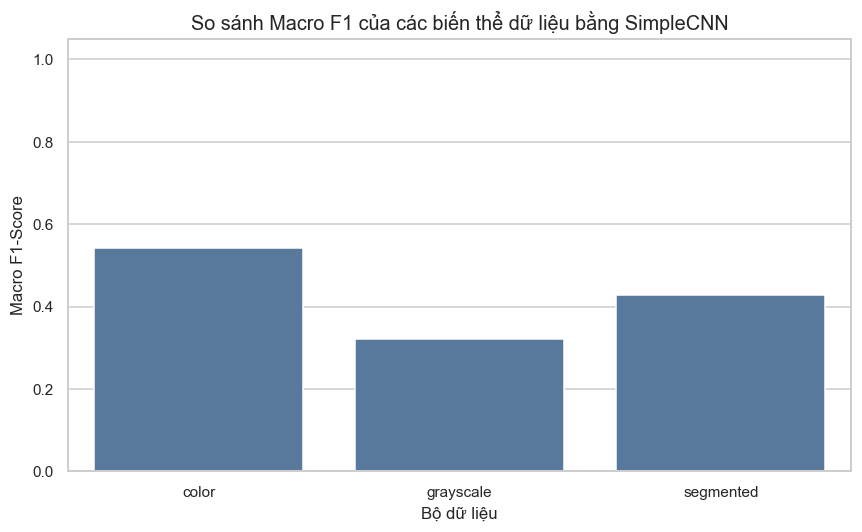

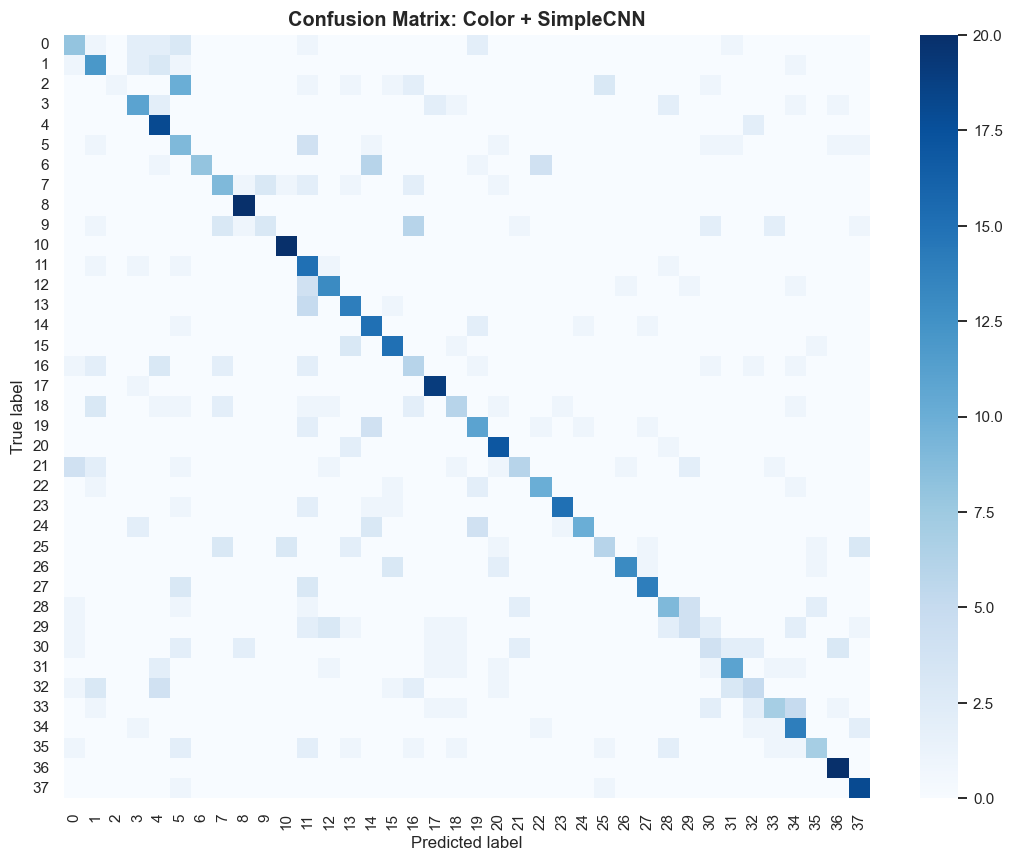

array([[ 8,  1,  0, ...,  0,  0,  0],
       [ 1, 12,  0, ...,  0,  0,  0],
       [ 0,  0,  1, ...,  0,  0,  0],
       ...,
       [ 1,  0,  0, ...,  7,  0,  0],
       [ 0,  0,  0, ...,  0, 20,  0],
       [ 0,  0,  0, ...,  0,  0, 18]], shape=(38, 38))

In [19]:
results_df = pd.DataFrame(results)
print("=== KẾT QUẢ BASELINE SIMPLECNN ===")
display(results_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x='dataset', y='macro_f1', color='#4C78A8')
plt.title('So sánh Macro F1 của các biến thể dữ liệu bằng SimpleCNN')
plt.xlabel('Bộ dữ liệu')
plt.ylabel('Macro F1-Score')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'dataset_comparison_chart.png')
plt.show()

# Vẽ Confusion Matrix mẫu của Color + SimpleCNN.
preds, labels = predictions['color_SimpleCNN']
plot_confusion_heatmap(
    labels,
    preds,
    labels=list(range(NUM_CLASSES)),
    title='Confusion Matrix: Color + SimpleCNN',
    save_path=RESULTS_DIR / 'confusion_matrices' / 'color_SimpleCNN_cm.png',
    figsize=(10, 8),
)


# 09. Phân tích So sánh chéo (Dataset Comparison)
Tính giá trị trung bình hiệu năng để phân tích ảnh hưởng của phương án tiền xử lý ảnh và kiến trúc mô hình.

In [20]:
print("=== Hiệu năng trung bình theo Dataset ===")
display(results_df.groupby('dataset')[['accuracy', 'macro_f1']].mean())

print("\n=== Hiệu năng trung bình theo Model ===")
display(results_df.groupby('model')[['accuracy', 'macro_f1']].mean())


=== Hiệu năng trung bình theo Dataset ===


,accuracy,macro_f1
dataset,,
color,0.560265,0.543068
grayscale,0.353642,0.320558
segmented,0.451656,0.427338



=== Hiệu năng trung bình theo Model ===


,accuracy,macro_f1
model,,
SimpleCNN,0.455188,0.430321


# 10. Xuất Kết quả Thực nghiệm (Export Results)
Lưu bảng kết quả và lịch sử huấn luyện thành file CSV để làm dữ liệu đầu vào cho các phase sau.

In [21]:
results_df.to_csv(RESULTS_DIR / 'baseline_results.csv', index=False)

history_records = []
for key, hist in histories.items():
    d_name, m_name = key.split('_')
    for epoch, (t_loss, v_loss, v_f1) in enumerate(zip(hist['train_loss'], hist['val_loss'], hist['val_f1']), 1):
        history_records.append({
            'dataset': d_name, 'model': m_name, 'epoch': epoch,
            'train_loss': t_loss, 'val_loss': v_loss, 'val_f1': v_f1
        })
pd.DataFrame(history_records).to_csv(RESULTS_DIR / 'training_history.csv', index=False)
print("Đã lưu kết quả baseline và training history thành công!")


Đã lưu kết quả baseline và training history thành công!


# 11. Báo cáo Nhận định khoa học (Final Analysis)
Tự động sinh nhận xét khoa học về hiệu năng chéo của các bộ dữ liệu và lưu thành file văn bản.

In [22]:
best_row = results_df.loc[results_df['macro_f1'].idxmax()]

summary = f"""=== BÁO CÁO PHÂN TÍCH THỰC NGHIỆM BASELINE PLANTVILLAGE ===
Ngày: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

1. Thực nghiệm tối ưu nhất:
   - Bộ dữ liệu: {best_row['dataset'].upper()}
   - Mô hình: {best_row['model']}
   - Macro F1: {best_row['macro_f1']:.4f} | Accuracy: {best_row['accuracy']:.4f}

2. Nhận định ảnh hưởng tiền xử lý:
   - Phase 03 chỉ dùng SimpleCNN/TinyCNN để so sánh công bằng giữa các biến thể dữ liệu.
   - Bộ Color giữ lại thông tin màu sắc bệnh học quan trọng như vàng lá, đốm nâu, rỉ sắt.
   - Bộ Segmented giảm nhiễu hậu cảnh, có thể giúp mô hình tập trung hơn vào vùng lá.
   - Bộ Grayscale có thể giảm hiệu năng nếu màu sắc là tín hiệu quan trọng của bệnh.

3. Kiến nghị cho Phase tiếp theo:
   - Chọn biến thể dữ liệu có Macro F1 tốt nhất làm hướng chính cho các phase sau.
   - Giữ SimpleCNN làm baseline học từ đầu trong Phase 04-07.
   - Chỉ đưa MobileNetV2/EfficientNet-B0 vào Phase 08 để tách rõ baseline đơn giản và transfer learning.
"""

with open(REPORTS_DIR / 'baseline_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("Đã ghi báo cáo baseline_summary.txt thành công!")
print("\n" + summary)


Đã ghi báo cáo baseline_summary.txt thành công!

=== BÁO CÁO PHÂN TÍCH THỰC NGHIỆM BASELINE PLANTVILLAGE ===
Ngày: 2026-05-24 11:31:02

1. Thực nghiệm tối ưu nhất:
   - Bộ dữ liệu: COLOR
   - Mô hình: SimpleCNN
   - Macro F1: 0.5431 | Accuracy: 0.5603

2. Nhận định ảnh hưởng tiền xử lý:
   - Phase 03 chỉ dùng SimpleCNN/TinyCNN để so sánh công bằng giữa các biến thể dữ liệu.
   - Bộ Color giữ lại thông tin màu sắc bệnh học quan trọng như vàng lá, đốm nâu, rỉ sắt.
   - Bộ Segmented giảm nhiễu hậu cảnh, có thể giúp mô hình tập trung hơn vào vùng lá.
   - Bộ Grayscale có thể giảm hiệu năng nếu màu sắc là tín hiệu quan trọng của bệnh.

3. Kiến nghị cho Phase tiếp theo:
   - Chọn biến thể dữ liệu có Macro F1 tốt nhất làm hướng chính cho các phase sau.
   - Giữ SimpleCNN làm baseline học từ đầu trong Phase 04-07.
   - Chỉ đưa MobileNetV2/EfficientNet-B0 vào Phase 08 để tách rõ baseline đơn giản và transfer learning.

